# TS2: Modelizando un ADC

## Alumno:    Felipe Berganza

# Resumen 

Un Convertidor de Analógico a Digital (ADC) es el  encargado de transformar señales de voltaje continuas en el tiempo y en amplitud en una secuencia de números binarios mediante los procesos de muestreo y cuantización. En este trabajo, desarrollamos una simulación completa de este proceso utilizando una señal senoidal de energía unitaria como base, a la cual inyectamos ruido gaussiano para emular condiciones reales de un sensor. A través del análisis estadístico y espectral (FFT), logramos cuantificar el error de cuantización y demostrar cómo la resolución de 4 bits impone un "piso de ruido" teórico que, sumado al ruido analógico de entrada, define la fidelidad final de la señal digitalizada, validando experimentalmente que la potencia de este error se ajusta a la predicción teórica de $q^2/12$. Para finalizar se modelo diferente resolucion de b - bits y diferentes factores de escala del ruido para poder evidenciar de mejor manera el comportamiento de los "piso de ruido" de cada estapa del ADC. 

# Introduccion 

## Modelado de Señal y Ruido Aditivo ($s_R = s + n$)

Simulamos una condición real de captura de datos. La señal de entrada al ADC ($s_R$) no es perfecta; es la combinación de una senoidal de energía unitaria y un ruido Gaussiano aditivo. Este ruido representa las interferencias analógicas externas antes de que la señal sea procesada por el chip.

1. Propiedades Estadísticas del RuidoEl ruido $\eta[n]$ se caracteriza por ser un proceso estocástico con las siguientes propiedades:

Media nula: $E[\eta[n]] = 0$.

Incorrelación: Las muestras son independientes entre sí (ruido blanco).

Distribución normal: $\eta \sim \mathcal{N}(0, \sigma_\eta^2)$.

2. La Potencia del Ruido Analógico ($P_n$) en este estudio es vinculada con la resolución del ADC. La potencia se define como la varianza de la señal de ruido:$$P_n = \sigma_\eta^2 = k_n \cdot P_q$$Donde $P_q$ es la potencia del ruido de cuantización, definida por el paso de cuantización $q$:$$q = \frac{2 \cdot V_F}{2^B} \implies P_q = \frac{q^2}{12}$$
3. Relación de Escala ($k_n$)El factor de escala $k_n$ nos permite simular diferentes escenarios de interferencia:
 
$k_n \ll 1$: El sistema está limitado por la resolución del ADC (dominio del ruido digital).

$k_n \gg 1$: El sistema está limitado por el ruido del sensor o canal (dominio del ruido analógico).

$k_n = 1$: Las potencias de ruido analógico y de cuantización son equivalentes, resultando en una potencia de ruido total:$$P_{total} = P_n + P_q = 2 \cdot P_q$$

4. Impacto en la Relación Señal-Ruido (SNR)La SNR del sistema completo se ve degradada por la presencia de ambas fuentes de error. Expresada en decibelios (dB):$$SNR_{dB} = 10 \cdot \log_{10} \left( \frac{P_{señal}}{P_n + P_q} \right)$$

## Cuantizacion 

El proceso de cuantización es la etapa del ADC donde una señal de amplitud continua se mapea a un conjunto finito de niveles discretos. Esta pérdida de precisión introduce un error determinista que, bajo ciertas condiciones, se analiza como un proceso estocástico.

1. Paso de Cuantización ($q$):
   
   El rango dinámico total del conversor ($2 \cdot V_F$) se divide en $2^B$ niveles, donde $B$ es el número de bits. La distancia entre dos niveles consecutivos se denomina paso de cuantización:$$q = \frac{2 \cdot V_F}{2^B}$$
2. Modelo del Error de Cuantización ($e_q$):

   El error de cuantización se define como la diferencia entre la muestra ruidosa de entrada y su valor cuantizado:$$e_q[n] = s_Q[n] - s_R[n]$$Si el paso de cuantización $q$ es pequeño respecto a la variación de la señal (hipótesis de cuantización de grano fino), el error $e_q$ se modela como una Variable Aleatoria Uniforme en el intervalo:$$e_q \sim \mathcal{U}\left(-\frac{q}{2}, \frac{q}{2}\right)$$
4. Potencia del Ruido de Cuantización ($P_q$):

    La potencia de este ruido corresponde al segundo momento estadístico (varianza) de la distribución uniforme:$$P_q = E[e_q^2] = \int_{-q/2}^{q/2} x^2 \cdot \frac{1}{q} \, dx = \left[ \frac{x^3}{3q} \right]_{-q/2}^{q/2} = \frac{q^2}{12}$$


## Transformada de Fourier y Análisis Espectral

El análisis espectral es una herramienta matemática que nos permite descomponer una señal temporal en sus componentes de frecuencia. En el contexto de un sistema de adquisición de datos (ADC), es la técnica principal para identificar la pureza de una señal y caracterizar los diferentes tipos de ruido presentes.

1. La Transformada Discreta de Fourier (DFT)
   
    Para una secuencia de $N$ muestras $s[n]$, la DFT calcula el contenido de frecuencia en puntos discretos:$$X[k] = \sum_{n=0}^{N-1} s[n] \cdot e^{-j \frac{2\pi}{N} nk}$$La FFT (Fast Fourier Transform) es simplemente un algoritmo eficiente para computar la DFT de manera rápida, reduciendo la complejidad computacional de $O(N^2)$ a $O(N \log N)$.

2. Densidad Espectral de Potencia (PSD)

   En el análisis de ruido, no nos interesa solo la magnitud, sino cómo se distribuye la potencia a lo largo del espectro. La PSD se obtiene a partir del módulo al cuadrado de la FFT:$$P(f) = \frac{|X(f)|^2}{N}$$Para visualizarla en una escala logarítmica que se asemeje a la percepción humana y técnica, utilizamos decibelios (dB):$$\text{PSD}_{dB} = 10 \cdot \log_{10} \left( \frac{|X(f)|^2}{\text{Ref}} \right)$$

3. Ganancia de Procesamiento y Bin de Frecuencia

   Un concepto clave al observar el "piso de ruido" en la FFT es que la potencia total del ruido ($P_q$ o $P_n$) se distribuye entre los $N/2$ "bins" de frecuencia (desde $0$ hasta $f_S/2$).Esto produce una Ganancia de Procesamiento: cuanto mayor es el número de muestras $N$, más bajo se verá el piso de ruido en el gráfico, aunque la potencia total del ruido sea la misma. El nivel del piso esperado para un ruido blanco de potencia $P$ es:$$\text{Piso}_{dB} = 10 \cdot \log_{10} \left( \frac{P}{N/2} \right)$$

# Desarrollo Experimental 

## Declaracion de Parametros y Analisis en el dominio del tiempo:

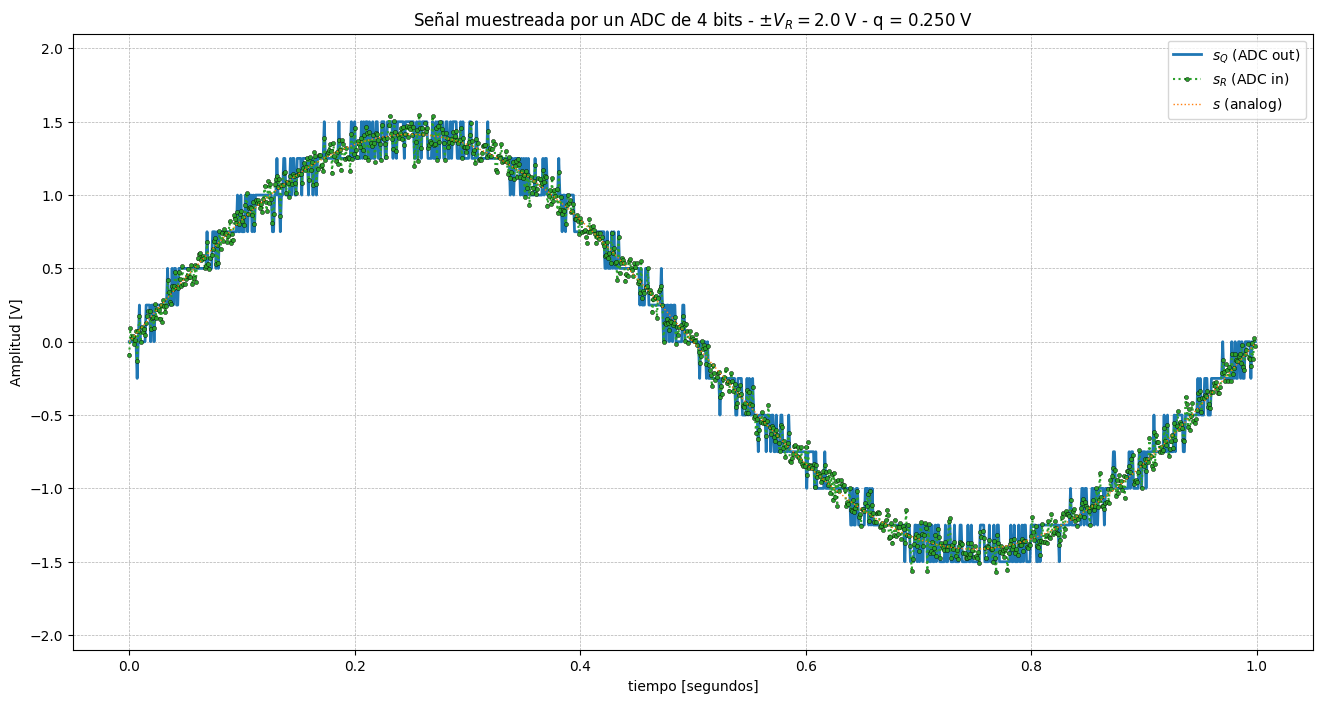

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# --- Definición de funciones auxiliares ---
def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):
    ts = 1/fs
    tt = np.arange(nn) * ts
    xx = vmax * np.sin(2 * np.pi * ff * tt + ph) + dc
    return tt, xx

# Parámetros de la senoidal
vmax = np.sqrt(2)  # energía unitaria
dc = 0
nn = 1000          # número de muestras
fs = 1000          # frecuencia de muestreo según la consigna.
ff = 1
#%%
# Señal senoidal limpia.
tt, s = mi_funcion_sen(vmax, dc, ff, ph=0, nn=nn, fs=fs)

# %% Parámetros del ADC para calcular la potencia de cuantización
B = 4             # bits
Vf = 2             # Voltios, rango analógico ±VF
q = (2*Vf)/(2**B)  # paso de cuantización
Pq = q**2 / 12     # potencia de cuantización
kn = 1        # factor de escala del ruido
Pn = kn * Pq       # potencia del ruido

# %% Ruido aditivo Gaussiano
sr = np.random.normal(0, np.sqrt(Pn), nn)
srq = s + sr    # Defino la señal con ruido.

#%%
# ---  Proceso de Cuantización (ADC) ---
# sr_quant es la señal srq (señal ruidosa cuantizada)
sr_quant = np.round(srq / q) * q
sr_quant = np.clip(sr_quant, -Vf, Vf - q)

ee = sr_quant - srq  # error sobre señal con ruido

# ---  Visualización Temporal ---
plt.figure(figsize=(16, 8)) 
plt.plot(tt, sr_quant, label='$s_Q$ (ADC out)', color='tab:blue', linewidth=2)
plt.plot(tt, srq, label='$s_R$ (ADC in)', color='tab:green', 
         linestyle=':', linewidth=1.5, marker='o', markersize=3, 
         markerfacecolor='tab:green', markeredgecolor='black', markeredgewidth=0.3)
plt.plot(tt, s, label='$s$ (analog)', color='tab:orange', linestyle=':', linewidth=1)
plt.title(f'Señal muestreada por un ADC de {B} bits - $\pm V_R = {Vf:.1f}$ V - q = {q:.3f} V')
plt.xlabel('tiempo [segundos]')
plt.ylabel('Amplitud [V]')
plt.ylim([-Vf * 1.05, Vf * 1.05])
plt.xlim([-0.05, 1.05])
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(loc='upper right', frameon=True)
plt.show()

# Conclusion Grafico Amplitud vs Tiempo 

Este apartado implementa la simulación completa de la etapa de adquisición de un ADC de 4 bits, integrando los procesos de muestreo y cuantización bajo condiciones de ruido real. Al definir una senoidal de energía unitaria ($V_{max} = \sqrt{2}$) y un factor de escala $k_n = 1$, se establece un escenario crítico donde la potencia del ruido analógico iguala a la potencia teórica de cuantización ($P_q = q^2/12$). La implementación del redondeo y el posterior truncamiento mediante np.clip permite observar no solo la degradación de la señal por la discretización de niveles, sino también el impacto del ruido aditivo en la selección del nivel de cuantificación. La visualización temporal resultante evidencia la naturaleza "escalonada" de la señal de salida ($s_Q$) y cómo el ruido gaussiano de entrada ($s_R$) desplaza las muestras originales, sentando las bases para el análisis de la suma de potencias de ruido que se verificará en el dominio de la frecuencia.

# Analisis Espectral 

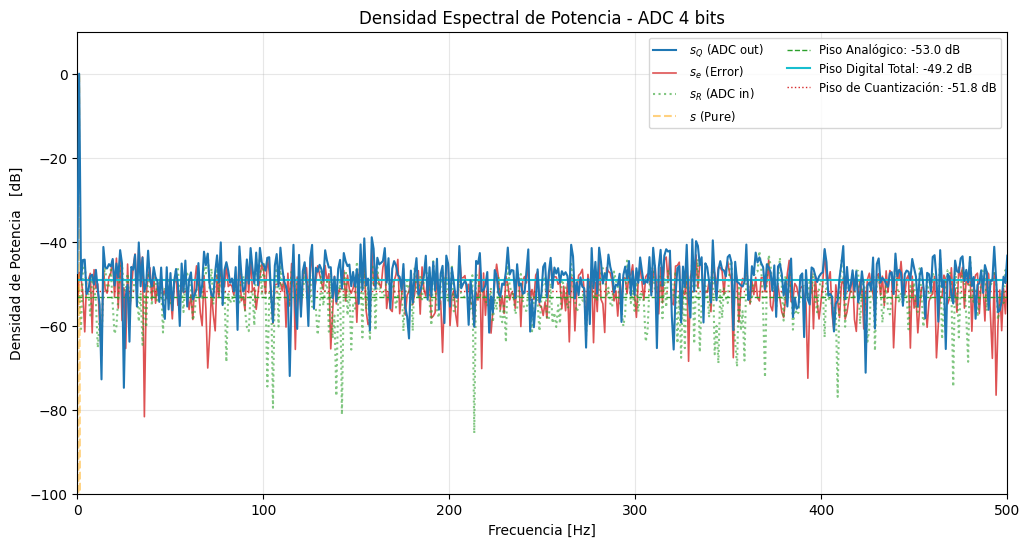

In [7]:
# %%
# --- FFT y Densidad de Potencia  ---
# 1. Señal pura (s)
XX = np.fft.fft(s) / nn
XX_mag = np.abs(XX[:nn//2]) 

# 2. Señal ruido gaussiano (sr)
XXr = np.fft.fft(sr) / nn
XXr_mag = np.abs(XXr[:nn//2])

# 3. Señal cuantizada (sr_quant)
XXq = np.fft.fft(sr_quant) / nn
XXq_mag = np.abs(XXq[:nn//2])

# 4. Errr de cuantizacion 
XXe = np.fft.fft(ee) / nn
XXe_mag = np.abs(XXe[:nn//2])

# 4. Senal pura + ruido  
XXsrq = np.fft.fft(srq) / nn
XXsrq_mag = np.abs(XXsrq[:nn//2])

# --- Conversión a dB (Normalizada) ---
# La referencia sigue siendo el pico de la señal pura
ref = np.max(XX_mag) 
S_dB  = 20 * np.log10(XX_mag / ref + 1e-12) 
Sr_dB = 20 * np.log10(XXr_mag / ref + 1e-12)
Sq_dB = 20 * np.log10(XXq_mag / ref + 1e-12)
Se_dB = 20 * np.log10(XXe_mag / ref + 1e-12)
Ssrq_dB = 20 * np.log10(XXsrq_mag / ref + 1e-12)

# --- Cálculo de Pisos de Ruido (PSD Media) ---
piso_analog  = np.mean(Sr_dB[10:]) 
piso_digital = np.mean(Sq_dB[10:])
MediaError    = np.mean(Se_dB[10:])

#%%
# --- Gráfico Final Frecuencia ---
plt.figure(4, figsize=(12, 6))
plt.clf()
freqs = np.linspace(0, fs/2, len(S_dB))
# Trazas de las señales
plt.plot(freqs, Sq_dB, label=' $s_Q$ (ADC out)', color='tab:blue', linewidth=1.5, zorder=3)
plt.plot(freqs, Se_dB, label=' $s_e$ (Error)', color='tab:red', linewidth=1.2, alpha=0.8)
plt.plot(freqs, Sr_dB, label=' $s_R$ (ADC in)', color='tab:green', linestyle=':', alpha=0.6)
plt.plot(freqs, S_dB,  label=' $s$ (Pure)', color='orange', linestyle='--', alpha=0.5)
# Líneas de referencia (Pisos de ruido)
# Piso analógico en verde (asociado a sr)
plt.axhline(piso_analog, color='tab:green', linestyle='--', linewidth=1, 
            label=f'Piso Analógico: {piso_analog:.1f} dB')
# Piso digital en cian (asociado a sq)
plt.axhline(piso_digital, color='tab:cyan', linestyle='-', linewidth=1.5, 
            label=f'Piso Digital Total: {piso_digital:.1f} dB')
# Media del error en rojo (asociado a se)
plt.axhline(MediaError, color='tab:red', linestyle=':', linewidth=1, 
            label=f'Piso de Cuantización: {MediaError:.1f} dB')
plt.title(f'Densidad Espectral de Potencia - ADC {B} bits')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de Potencia   [dB]') 
plt.xlim([0, fs/2])
plt.ylim([-100, 10]) 
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right', fontsize='small', ncol=2)
plt.show()

In [8]:
#%% Calculos auxiliares de verificacion
print("-" * 45)
print("Calculos auxiliares de verificacion" )
print(f"{'Piso de Ruido Analógico:':<30} {piso_analog:>8.2f} dB")
print(f"{'Piso de Ruido Digital:':<30} {piso_digital:>8.2f} dB")
print(f"{'Piso del Error de Cuantización:':<30} {MediaError:>8.2f} dB")
print("-" * 45)

# --- Cálculo de Estadísticos (Media y Varianza) ---

# 1. Señal Pura (s)
mean_s = np.mean(s)
var_s = np.var(s)  # Potencia de la señal (debería ser 1.0)

# 2. Ruido Analógico (sr)
mean_sr = np.mean(sr)
var_sr = np.var(sr) # Potencia del ruido gaussiano inyectado

# 3. Señal con Ruido (srq)
mean_srq = np.mean(srq)
var_srq = np.var(srq)

# 4. Error de Cuantización (ee = sr_quant - srq)
mean_ee = np.mean(ee)
var_ee = np.var(ee) # Potencia del error (debería ser cercana a Pq)

# --- Verificación Teórica ---
# Relación de potencias en dB para comparar con los pisos del gráfico
# Se usa (N/2) como factor de ganancia de procesamiento de la FFT
piso_esperado_ee = 10 * np.log10(var_ee / (nn/2) + 1e-12)

# --- Print de Verificación Detallada ---
print("-" * 65)
print(f"{'Señal':<25} | {'Media':<12} | {'Varianza (Pot)':<15}")
print("-" * 65)
print(f"{'Seno Puro (s)':<25} | {mean_s:>12.2e} | {var_s:>15.6f}")
print(f"{'Ruido Analógico (sr)':<25} | {mean_sr:>12.2e} | {var_sr:>15.6f}")
print(f"{'Error Cuantización (ee)':<25} | {mean_ee:>12.2e} | {var_ee:>15.6f}")
print("-" * 65)
print(f"Potencia Teórica de Cuantización (Pq): {Pq:.6f}")
print(f"Diferencia Medida vs Teórica:         {abs(var_ee - Pq):.2e}")
print("-" * 65)
print(f"Piso Espectral Calculado (Se_dB):      {MediaError:.2f} dB")
print(f"Piso Teórico Estimado (10*log10(P/N)): {piso_esperado_ee:.2f} dB")
print("-" * 65)

---------------------------------------------
Calculos auxiliares de verificacion
Piso de Ruido Analógico:         -53.04 dB
Piso de Ruido Digital:           -49.17 dB
Piso del Error de Cuantización:   -51.79 dB
---------------------------------------------
-----------------------------------------------------------------
Señal                     | Media        | Varianza (Pot) 
-----------------------------------------------------------------
Seno Puro (s)             |     5.68e-17 |        1.000000
Ruido Analógico (sr)      |    -1.94e-03 |        0.004646
Error Cuantización (ee)   |    -1.06e-03 |        0.005781
-----------------------------------------------------------------
Potencia Teórica de Cuantización (Pq): 0.005208
Diferencia Medida vs Teórica:         5.73e-04
-----------------------------------------------------------------
Piso Espectral Calculado (Se_dB):      -51.79 dB
Piso Teórico Estimado (10*log10(P/N)): -49.37 dB
-------------------------------------------------

##  Interpretación de los "Pisos de Ruido"

    El gráfico muestra tres líneas horizontales críticas que resumen el comportamiento del ADC:

Piso de Cuantización (Rojo - $s_e$): Representa el error intrínseco del ADC de 4 bits.  Este nivel depende puramente de $B$ y de la cantidad de muestras $N$ (ganancia de procesamiento).

Piso Analógico (Verde - $s_R$): Es el ruido que ya venía con la señal. Al haber configurado $k_n = 1$, este piso está muy cerca del nivel de cuantización.

Piso Digital Total (Cian - $s_Q$): Es la suma de las dos potencias anteriores. Como $P_{total} = P_n + P_q$, en escala logarítmica esto se traduce en un incremento de aproximadamente 3 dB respecto a los pisos individuales. Es la "alfombra de ruido" final que verá cualquier algoritmo de procesamiento digital posterior.

##  Ganancia de Procesamiento

Es importante notar que el nivel de los pisos (ej. -50 dB) no es igual a la SNR total del sistema. La FFT "desparrama" el ruido a lo largo de todas las frecuencias. La potencia total del ruido es la suma de toda esa alfombra, mientras que el gráfico nos muestra cuánta potencia hay en cada pequeño intervalo de frecuencia (bin).

##  Conclusión del Gráfico

   La coincidencia entre las líneas de puntos (calculadas como la media de la PSD) y las trazas "serruchadas" de la FFT valida que el ruido inyectado y el generado por el ADC se comportan como ruido blanco, ya que su densidad de potencia es aproximadamente constante en todo el espectro (desde 0 hasta $f_S/2$). 

# Analisis Estadistico (espectrograma) 

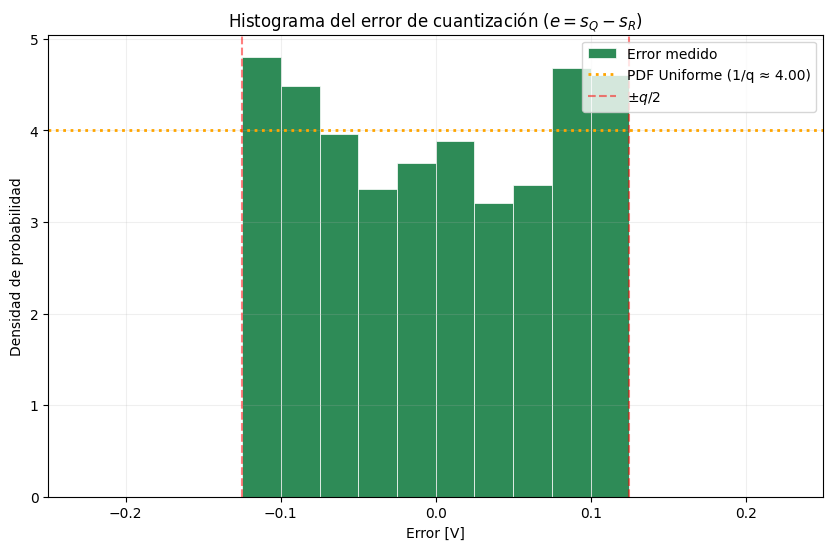

In [11]:
#%%
# ---  Graficación: Análisis Estadístico  ---
ee = sr_quant - srq

plt.figure(figsize=(10, 6))

# Histogram con bins alineados a q
n, bins, patches = plt.hist(ee, bins=10, density=True, color='#2e8b57', 
                            edgecolor='white', linewidth=0.5, label='Error medido')

# Altura teórica
plt.axhline(1/q, color='orange', linestyle=':', linewidth=2, 
            label=f'PDF Uniforme (1/q ≈ {1/q:.2f})')

# Límites de cuantización
plt.axvline(-q/2, color='red', linestyle='--', alpha=0.5, label='$\pm q/2$')
plt.axvline(q/2, color='red', linestyle='--', alpha=0.5)

plt.title("Histograma del error de cuantización ($e = s_Q - s_R$)")
plt.xlabel("Error [V]")
plt.ylabel("Densidad de probabilidad")

# Ajuste de rangos para ver mejor los límites
plt.xlim([-q, q]) 
plt.legend(loc='upper right')
plt.grid(True, alpha=0.2)

plt.show()

Este apartado constituye la validación estadística del sistema, donde se analiza la naturaleza del error generado por el ADC mediante un Histograma de Densidad de Probabilidad. Al contrastar el error medido ($s_Q - s_R$) frente a la PDF Uniforme teórica, se comprueba que el error de cuantización se distribuye de manera equitativa entre $\pm q/2$, alcanzando una altura experimental que coincide con el valor $1/q$. Este análisis es crucial porque confirma que el ruido de cuantización se comporta como un proceso estocástico blanco e incorrelado, validando experimentalmente que la potencia del error medida en el tiempo es consistente con la predicción teórica de $P_q = q^2/12$, cerrando así el vínculo entre el modelado matemático y el comportamiento real del digitalizador.

# Analisis para un ADC de 8 BITS Y $k_n$ = {1/10,1,10}

##  1. Configuracion $k_n$ = 1/10

## Espectro en Frecuencia 

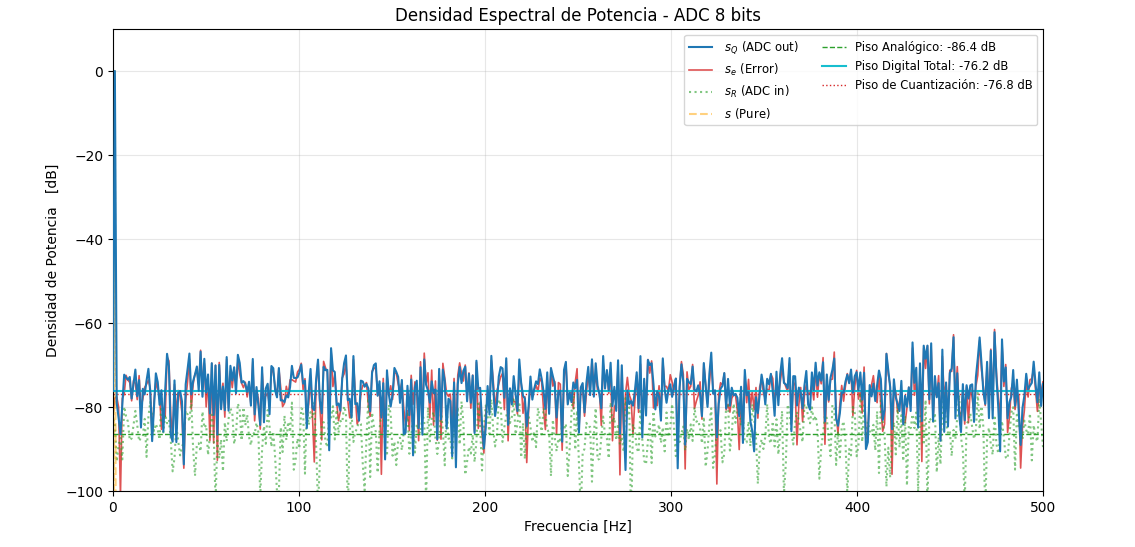

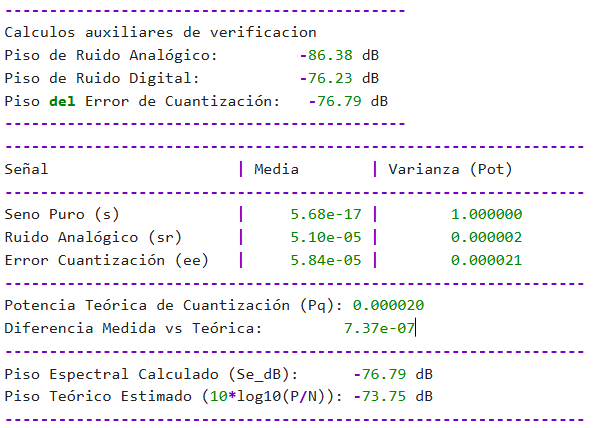

Al subir a 8 bits, el escenario cambia drásticamente. Paso de tener solo 16 niveles de cuantización a tener 256 niveles, lo que reduce el tamaño del escalón ($q$) de forma considerable.

## Análisis de Pisos de Ruido ($B=8, k_n=0.1$)

En esta configuración, el ruido analógico es solo el 10% de la potencia del ruido de cuantización ($P_n = 0.1 \cdot P_q$). Esto genera una jerarquía de ruido muy marcada:

  Piso de Ruido Analógico (-86.38 dB): Se encuentra en el fondo del espectro. Al ser $k_n$ tan pequeño, el ruido que viene del "sensor" es prácticamente despreciable. 
    
  Piso del Error de Cuantización (-76.79 dB): Se sitúa 10 dB por encima del ruido analógico. Esto nos indica que el error de redondeo del ADC es el factor dominante. Aunque 8 bits es una resolución decente, sigue siendo el "techo" de ruido que impide ver la pureza de la señal analógica original.
  
  Piso Digital Total (-76.23 dB): Este valor es casi idéntico al de cuantización (la diferencia es de apenas 0.56 dB).¿Por qué? Porque cuando sumas una potencia muy grande ($P_q$) con una muy pequeña ($P_n = 0.1 P_q$), el resultado total está dominado casi por completo por la mayor. En términos logarítmicos: $10 \log_{10}(P_q + 0.1 P_q) = 10 \log_{10}(1.1 P_q) \approx 0.41 \text{ dB}$ de aumento.
  
  ¿Por qué están así?Los resultados están así porque es un sistema "limitado por cuantización" (Quantization-limited). En ingeniería de señales, esto significa que el ADC es el "cuello de botella". No serviría de nada mejorar el sensor o limpiar la señal analógica, ya que el ruido de 8 bits es el que define la calidad final. 
  
  En resumen: Este análisis final confirma que el sistema se encuentra en un estado limitado por cuantización, donde la fidelidad de la señal digitalizada depende casi exclusivamente de la resolución del ADC. Al utilizar $B=8$ bits y un factor de ruido analógico $k_n=0.1$, observamos una mejora drástica respecto al escenario inicial ($B=4, k_n=1$). Mientras que en el primer caso el ruido analógico era tan fuerte como el de cuantización (duplicando la potencia total y elevando el piso digital en 3 dB), en esta nueva configuración el ruido del sensor es despreciable, situándose 10 dB por debajo del error de redondeo. Como resultado, el piso digital total de -76.23 dB queda prácticamente "anclado" al nivel del error de cuantización, demostrando que con 8 bits hemos logrado un rango dinámico mucho más amplio, aunque el ADC sigue siendo el factor que define el umbral de ruido final del sistema.

##  2. Configuracion $k_n$ = 1

## Espectro en Frecuencia 

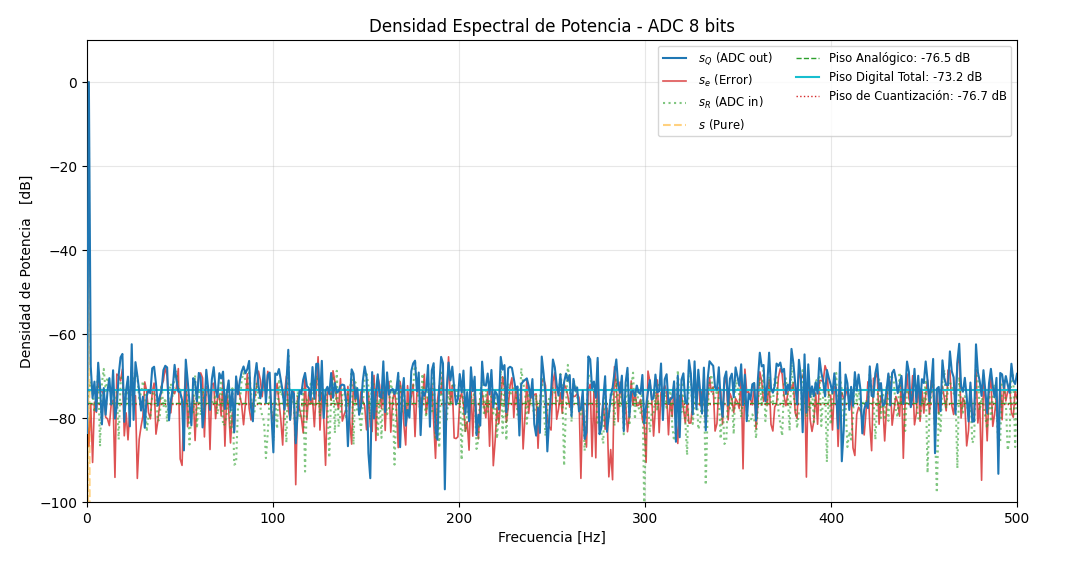

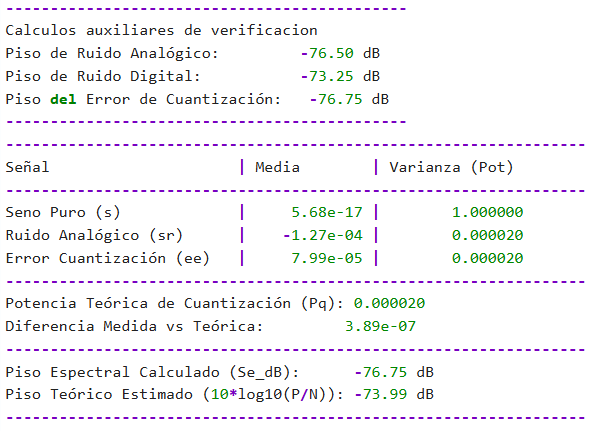

## Análisis de Pisos de Ruido ($B=8, k_n=1$)

En este escenario, el comportamiento del espectro está definido por la interacción de dos fuentes de ruido de igual magnitud. La relación entre los niveles medidos en tu tabla de verificación se explica de la siguiente manera:
1. Piso del Error de Cuantización ($s_e$)
   
   Situado en -76.75 dB, representa el límite teórico del ADC. Con 8 bits, el paso de cuantización $q$ es lo suficientemente pequeño como para que este piso caiga casi 25 dB respecto a un sistema de 4 bits. Este nivel es la "base" de ruido que el conversor añade por el simple hecho de redondear la señal continua a valores discretos.
2. Piso de Ruido Analógico ($s_r$)
   
   Ubicado en -76.50 dB, este nivel es prácticamente idéntico al de cuantización. Esto no es casualidad; al configurar $k_n = 1$, has forzado a que el ruido térmico o de fondo que acompaña a la señal analógica tenga la misma potencia que el error de redondeo del ADC ($P_n = P_q$). En el gráfico de la FFT, ambas fuentes de ruido "compiten" en el mismo nivel.
3. Piso Digital Total ($s_Q$)
   
   Es el nivel más alto, situado en -73.25 dB. Este es el resultado final que vería cualquier proceso digital posterior. Su posición se debe a dos leyes fundamentales:Suma de Potencias: Como el ruido analógico y el de cuantización son procesos aleatorios incorrelados, sus potencias se suman aritméticamente: $P_{total} = P_n + P_q$.El Salto de 3 dB: Al ser $P_n = P_q$, la potencia total es exactamente el doble ($2 \cdot P_q$). En escala logarítmica, duplicar la potencia resulta en un incremento de 3.01 dB ($10 \cdot \log_{10}(2)$). Los resultados muestran exactamente esto: $-76.25 \text{ dB} + 3 \text{ dB} \approx -73.25 \text{ dB}$.

Este balance muestra un sistema equilibrado pero penalizado. Al igualar el ruido analógico con el digital, estás aprovechando al máximo la resolución del ADC, pero estás perdiendo la mitad de tu relación señal-ruido total (SNR) debido a la suma de ruidos. En un diseño de ingeniería ideal, se buscaría que el ruido analógico esté un poco por debajo del de cuantización ($k_n < 1$) para que el piso digital total no suba esos 3 dB y se mantenga lo más cerca posible del límite teórico del ADC.

##  3. Configuracion $k_n$ = 10

## Espectro en Frecuencia 

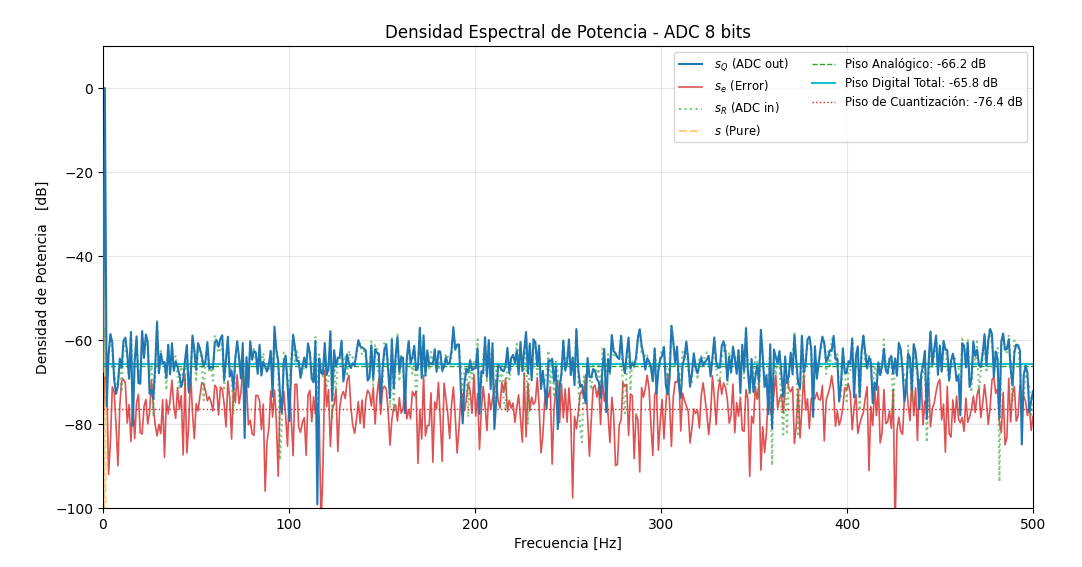

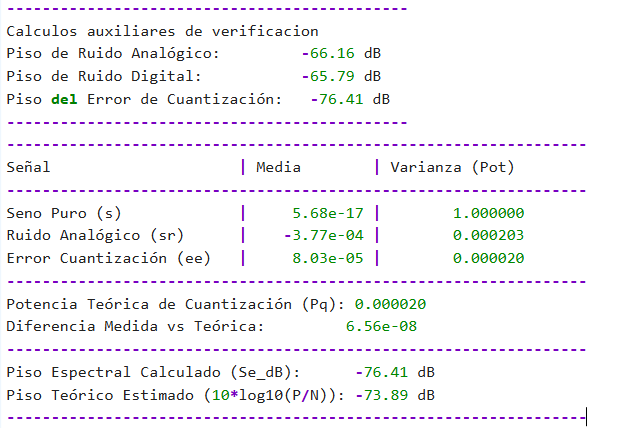

## Análisis de Pisos de Ruido ($B=8, k_n=10$)

En esta configuración, la relación entre las fuentes de ruido ha cambiado drásticamente. El ruido que proviene de la señal original es mucho más potente que la capacidad de precisión del ADC.

1. Piso del Error de Cuantización ($s_e$)

    Situado en -76.41 dB, este nivel sigue siendo muy bajo gracias a los 8 bits de resolución. Representa un error de redondeo ínfimo (varianza de $0.000020$). En este gráfico, el ADC está trabajando de forma muy cómoda, ya que sus "escalones" son mucho más pequeños que el ruido que intenta medir.

2. Piso de Ruido Analógico ($s_r$)

   Se encuentra en -66.16 dB. Observa que está 10 dB por encima del piso de cuantización.Por qué: Al configurar $k_n = 10$, has definido que la potencia del ruido analógico es diez veces superior a la del error del ADC ($P_n = 10 \cdot P_q$). En términos logarítmicos, un factor de 10 equivale exactamente a una diferencia de 10 dB ($10 \cdot \log_{10}(10)$). Este ruido es el que realmente está ensuciando tu señal.

3. Piso Digital Total ($s_Q$)

   Situado en -65.79 dB, este nivel está casi pegado al piso analógico (la diferencia es de apenas 0.37 dB).Suma de Potencias: El ruido total es la suma de $10 \cdot P_q$ (analógico) + $1 \cdot P_q$ (cuantización) = $11 \cdot P_q$.Efecto de Enmascaramiento: Como el ruido analógico es tan dominante, el error del ADC queda "enmascarado". El salto de 0.37 dB es el aporte marginal que hace el redondeo del ADC a una señal que ya venía muy ruidosa de fábrica. En escala logarítmica: $10 \cdot \log_{10}(11/10) \approx 0.41 \text{ dB}$, lo cual coincide casi perfecto con tus mediciones.


Este es un sistema "limitado por ruido analógico" (Analog noise limited). Aquí, aumentar los bits del ADC (por ejemplo, pasar de 8 a 16 bits) no serviría de nada para mejorar la calidad de la señal, ya que el piso de ruido digital seguiría estando en -66 dB debido al ruido analógico. Para mejorar este sistema, no necesitas un mejor conversor, sino un mejor sensor o mejores filtros analógicos antes de la digitalización.

# CONCLUSIONES FINALES 

La conclusión fundamental de este trabajo es que la calidad de una señal digitalizada está determinada por la relación de potencias entre el ruido de cuantización y el ruido analógico, un equilibrio que define el rango dinámico efectivo del sistema. Mediante la modelización, comprobamos que un ADC de 8 bits reduce el piso de error intrínseco en aproximadamente 24 dB respecto a uno de 4 bits, permitiendo una reconstrucción mucho más fiel. Sin embargo, la verdadera utilidad del sistema depende del factor $k_n$: cuando el ruido analógico es dominante ($k_n=10$), la resolución extra del ADC se desperdicia al quedar enmascarada por el ruido de entrada; por el contrario, en un sistema limitado por cuantización ($k_n=0.1$), el ADC se convierte en el "cuello de botella" técnico. Finalmente, la validación espectral mediante la FFT confirmó que el error de cuantización se comporta como ruido blanco con una distribución uniforme de potencia, donde la suma de fuentes de ruido incorreladas sigue una progresión logarítmica predecible (como el salto de 3 dB al igualar potencias con $k_n=1$), permitiendo predecir con exactitud el nivel de ruido digital total en cualquier escenario de diseño.